<a href="https://colab.research.google.com/github/HanifFaishalH/PCVK25_3F_15/blob/master/Week5_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 5 - Histogram, Histogram Equalization, Dithering

Nama : Hanif Faishal Hilmi

Kelas : TI-3F

NIM : 2341720116

## Percobaan D1 HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Import library yang akan digunakan

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

3. Membuat histogram citra

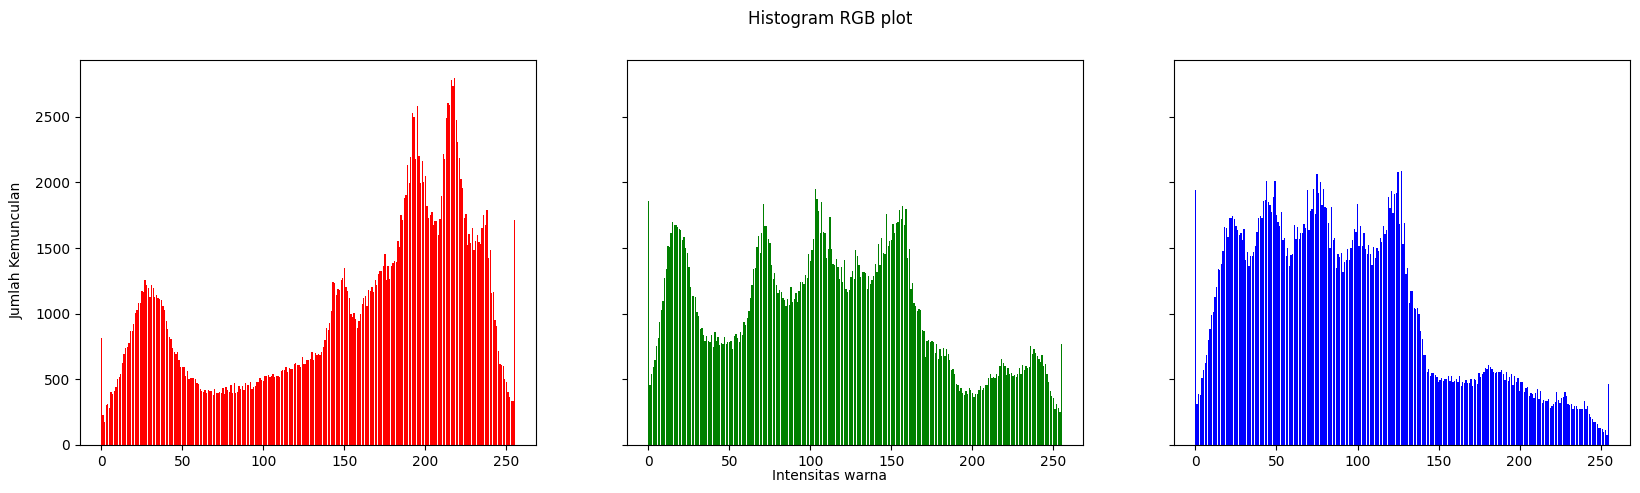

In [3]:
img = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
  for x in range(0,width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

## PERTANYAAN PRAKTIKUM D1

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh
NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

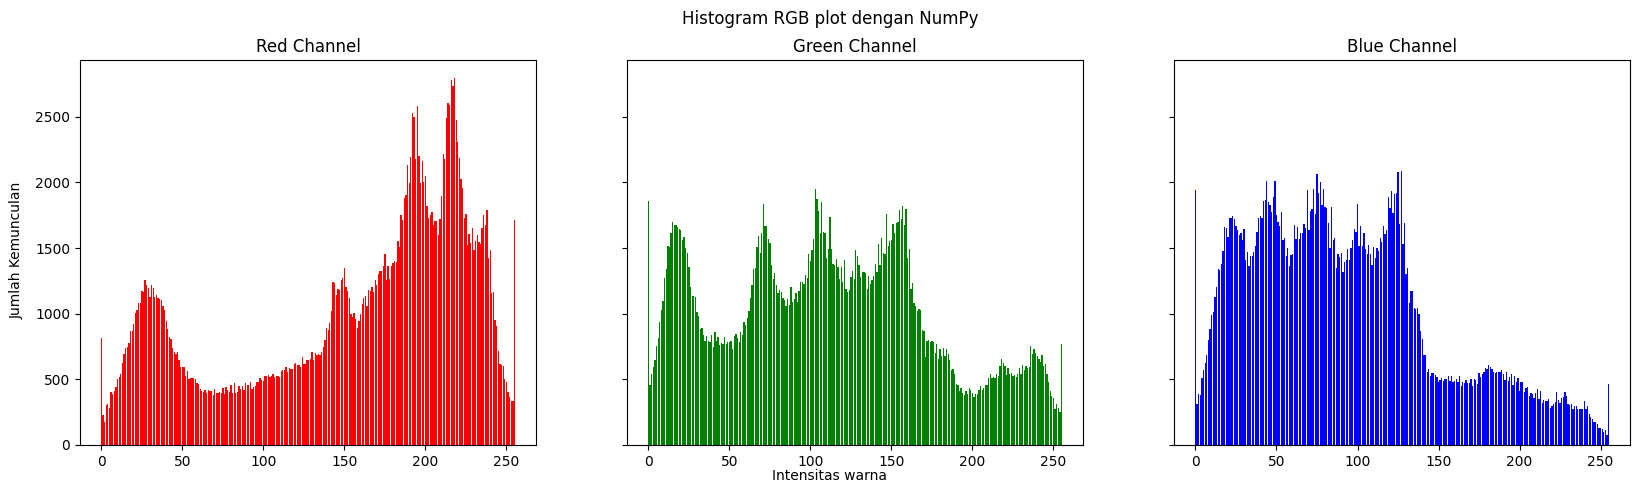

In [4]:
red_hist, red_bin = np.histogram(img[:,:,0].ravel(), bins=256, range=[0,256])
green_hist, green_bin = np.histogram(img[:,:,1].ravel(), bins=256, range=[0,256])
blue_hist, blue_bin = np.histogram(img[:,:,2].ravel(), bins=256, range=[0,256])

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot dengan NumPy')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')

axs[0].bar(names, red_hist, color='red')
axs[0].set_title('Red Channel')

axs[1].bar(names, green_hist, color='green')
axs[1].set_title('Green Channel')

axs[2].bar(names, blue_hist, color='blue')
axs[2].set_title('Blue Channel')
plt.show()

Output yang ditampilkan dengan menggunakan histogram library numpy sama seperti di percobaan.

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.


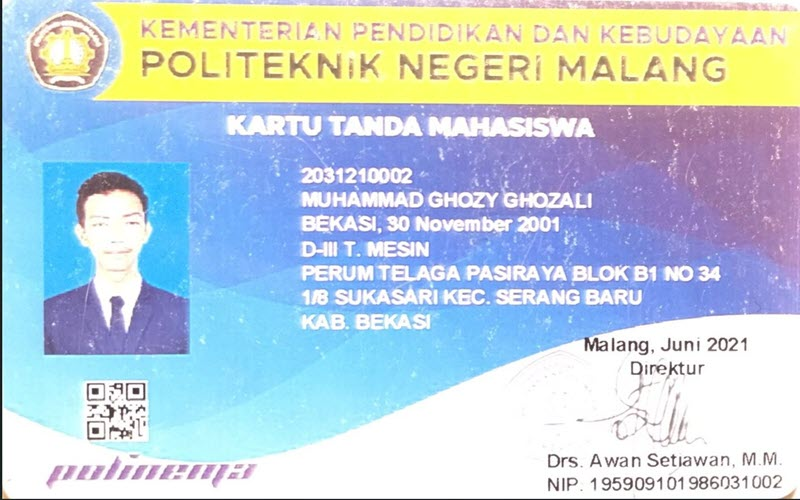

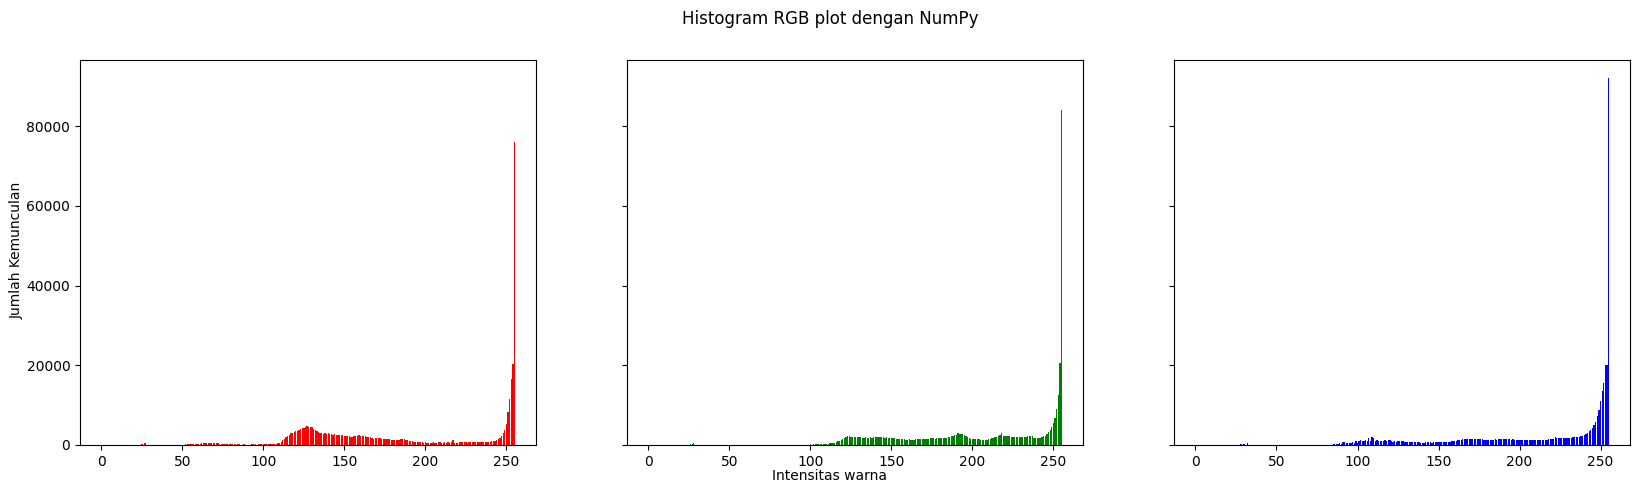

In [16]:
ktm = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/KTMLama.jpg')
ktm_rgb = cv.cvtColor(ktm, cv.COLOR_BGR2RGB)

cv2_imshow(ktm)

height, width, depth = np.shape(ktm_rgb)

ktm_red_hist, ktm_red_bin = np.histogram(ktm_rgb[:,:,0].ravel(), bins=256, range=[0,256])
ktm_green_hist, ktm_green_bin = np.histogram(ktm_rgb[:,:,1].ravel(), bins=256, range=[0,256])
ktm_blue_hist, ktm_blue_bin = np.histogram(ktm_rgb[:,:,2].ravel(), bins=256, range=[0,256])

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot dengan NumPy')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, ktm_red_hist, color='red')
axs[1].bar(names, ktm_green_hist, color='green')
axs[2].bar(names, ktm_blue_hist, color='blue')
plt.show()

Dari grafik tersebut. Distribusi piksel mayoritas dari channel berada di sisi kanan karena citra didominasi warna terang. Makanya, citra tersebut cenderung terang.

## D-2 PERCOBAAN HISTOGRAM EQUALIZATION

1. Buatlah histogram citra seperti output histogram equalization dan juga tampilan
gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

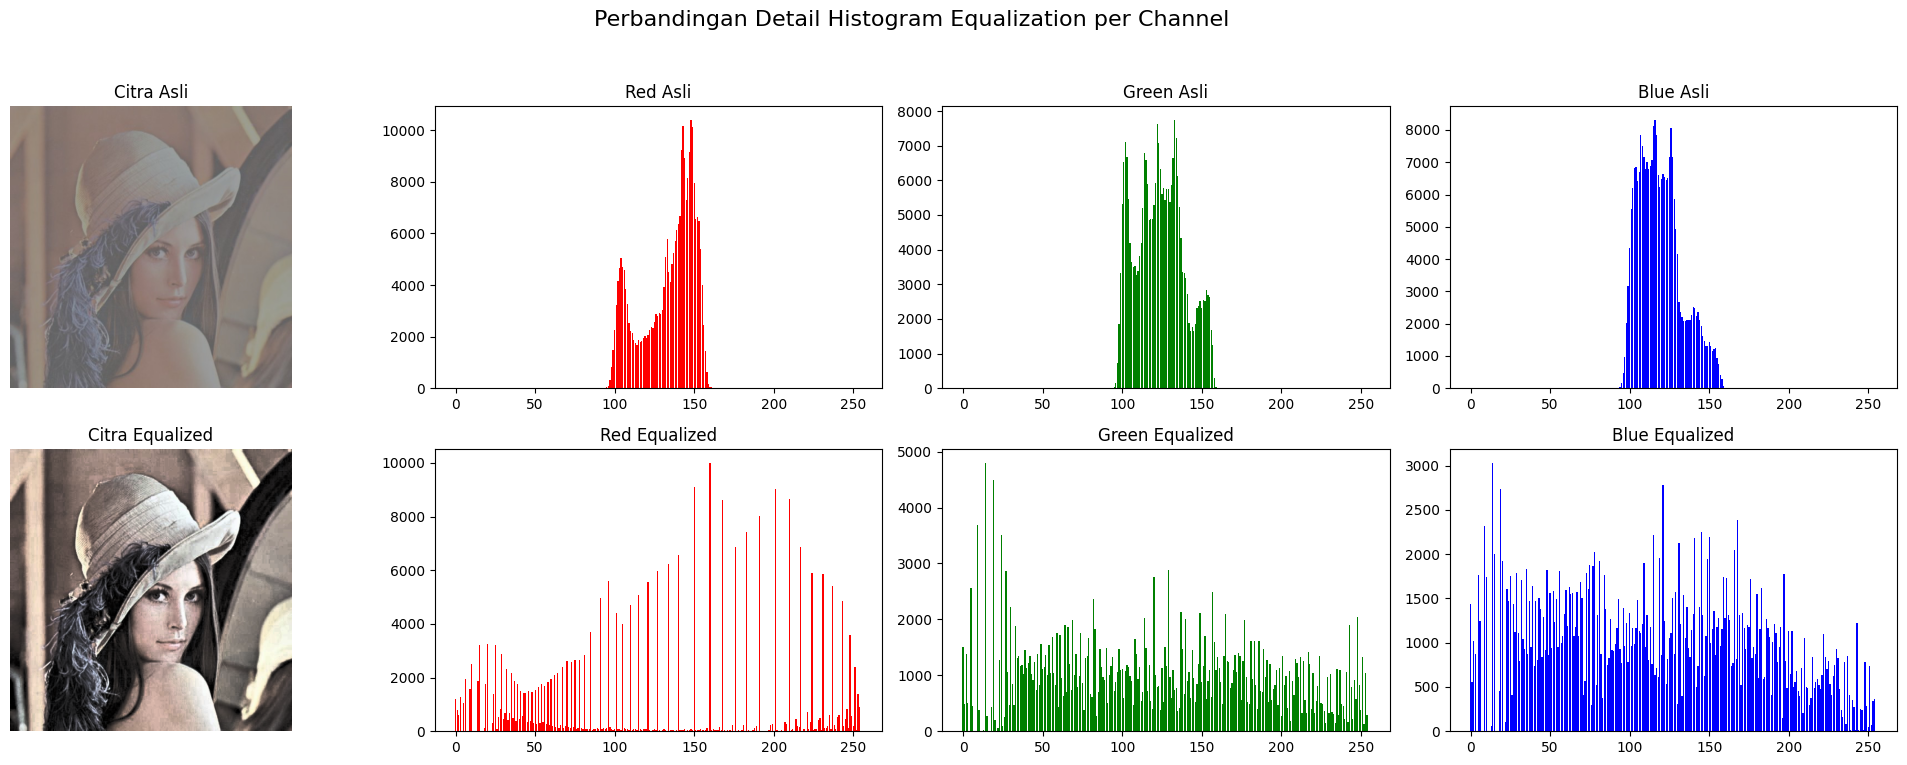

In [24]:
lena = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena_lc.jpg')
lena_rgb = cv.cvtColor(lena, cv.COLOR_BGR2RGB)

# Proses Histogram Equalization (tidak ada perubahan)
lena_hsv = cv.cvtColor(lena_rgb, cv.COLOR_RGB2HSV)
h, s, v = cv.split(lena_hsv)
hist_v, _ = np.histogram(v.ravel(), 256, [0, 256])
cdf_v = np.cumsum(hist_v)
cdf_min = cdf_v.min()
if cdf_min == 0:
  cdf_min = 1

cdf_normalized = ((cdf_v - cdf_min) * 255) / (cdf_v.max() - cdf_min)
transformation_map = cdf_normalized.astype('uint8')
v_equalized = transformation_map[v]
hsv_equalized = cv.merge([h, s, v_equalized])
lena_equalized_rgb = cv.cvtColor(hsv_equalized, cv.COLOR_HSV2RGB)

# 2. Hitung semua histogram yang dibutuhkan (tidak ada perubahan)
red_hist_orig, _ = np.histogram(lena_rgb[:,:,0].ravel(), bins=256, range=[0, 256])
green_hist_orig, _ = np.histogram(lena_rgb[:,:,1].ravel(), bins=256, range=[0, 256])
blue_hist_orig, _ = np.histogram(lena_rgb[:,:,2].ravel(), bins=256, range=[0, 256])

red_hist_eq, _ = np.histogram(lena_equalized_rgb[:,:,0].ravel(), bins=256, range=[0, 256])
green_hist_eq, _ = np.histogram(lena_equalized_rgb[:,:,1].ravel(), bins=256, range=[0, 256])
blue_hist_eq, _ = np.histogram(lena_equalized_rgb[:,:,2].ravel(), bins=256, range=[0, 256])

# 3. Setup Plotting Perbandingan
# PERBAIKAN 1: Mengubah sharey=True menjadi sharey=False (atau menghapusnya)
fig, axs = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
fig.suptitle('Perbandingan Detail Histogram Equalization per Channel', fontsize=16)

# --- BARIS 1: SEBELUM EQUALIZATION ---
axs[0, 0].imshow(lena_rgb)
axs[0, 0].set_title('Citra Asli')
axs[0, 0].axis('off')

names = np.arange(256)
axs[0, 1].bar(names, red_hist_orig, color='red')
axs[0, 1].set_title('Red Asli')
axs[0, 2].bar(names, green_hist_orig, color='green')
axs[0, 2].set_title('Green Asli')
axs[0, 3].bar(names, blue_hist_orig, color='blue')
axs[0, 3].set_title('Blue Asli')

# --- BARIS 2: SESUDAH EQUALIZATION ---
axs[1, 0].imshow(lena_equalized_rgb)
axs[1, 0].set_title('Citra Equalized')
axs[1, 0].axis('off')

axs[1, 1].bar(names, red_hist_eq, color='red')
axs[1, 1].set_title('Red Equalized')
axs[1, 2].bar(names, green_hist_eq, color='green')
axs[1, 2].set_title('Green Equalized')
axs[1, 3].bar(names, blue_hist_eq, color='blue')
axs[1, 3].set_title('Blue Equalized')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini.
  
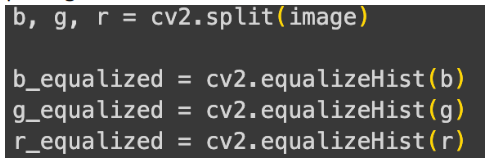

Lengkapi potongan kode tersebut! Bandingkan hasilnya. Apakah output muncul sama?

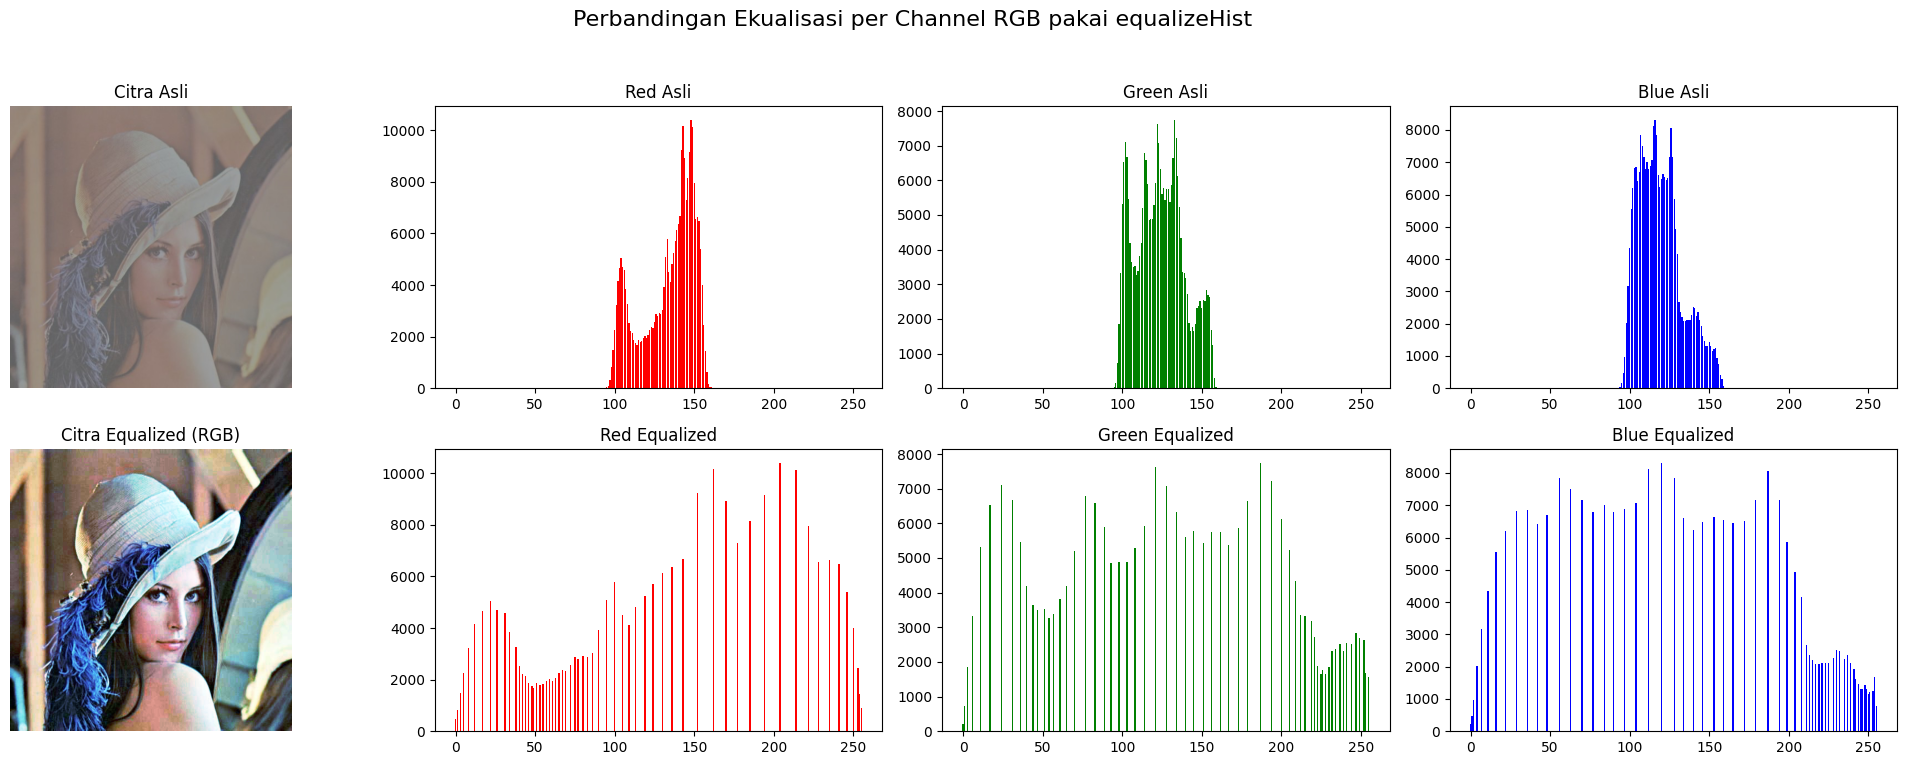

In [32]:
img = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena_lc.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

b, g, r = split = cv.split(img_rgb)

b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

img_equalized = cv.merge((b_equalized, g_equalized, r_equalized))

# Hitung semua histogram yang dibutuhkan untuk plotting
# Histogram untuk citra asli
red_hist_orig, _ = np.histogram(img_rgb[:,:,0].ravel(), bins=256, range=[0, 256])
green_hist_orig, _ = np.histogram(img_rgb[:,:,1].ravel(), bins=256, range=[0, 256])
blue_hist_orig, _ = np.histogram(img_rgb[:,:,2].ravel(), bins=256, range=[0, 256])

# Histogram untuk citra hasil ekualisasi
red_hist_eq, _ = np.histogram(img_equalized[:,:,0].ravel(), bins=256, range=[0, 256])
green_hist_eq, _ = np.histogram(img_equalized[:,:,1].ravel(), bins=256, range=[0, 256])
blue_hist_eq, _ = np.histogram(img_equalized[:,:,2].ravel(), bins=256, range=[0, 256])

# Setup Plotting Perbandingan
fig, axs = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Perbandingan Ekualisasi per Channel RGB pakai equalizeHist', fontsize=16)

# --- BARIS 1: SEBELUM EQUALIZATION ---
axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Citra Asli')
axs[0, 0].axis('off')

names = np.arange(256)
axs[0, 1].bar(names, red_hist_orig, color='red')
axs[0, 1].set_title('Red Asli')
axs[0, 2].bar(names, green_hist_orig, color='green')
axs[0, 2].set_title('Green Asli')
axs[0, 3].bar(names, blue_hist_orig, color='blue')
axs[0, 3].set_title('Blue Asli')

# --- BARIS 2: SESUDAH EQUALIZATION ---
axs[1, 0].imshow(img_equalized)
axs[1, 0].set_title('Citra Equalized (RGB)')
axs[1, 0].axis('off')

axs[1, 1].bar(names, red_hist_eq, color='red')
axs[1, 1].set_title('Red Equalized')
axs[1, 2].bar(names, green_hist_eq, color='green')
axs[1, 2].set_title('Green Equalized')
axs[1, 3].bar(names, blue_hist_eq, color='blue')
axs[1, 3].set_title('Blue Equalized')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Dari hasil histogram, kedua pengolahan tersebut mengeluarkan output yang berbeda. Di pengolahan pertama, distribusinya masih berkumpul di beberapa titik sehingga warnanya menjadi kurang natural. Di pengolahan ini, gambarnya jadi lebih natural dan penyebaran warna tiap piksel lebih merata